## Setup and Dependencies

In [1]:
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf
import datetime as dt

## Model Setup

In [2]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


## Model Execution

In [3]:
class Modifications():
    def __init__(self):
        self.months_in_quarter = 3

    def convert_years_to_quarters(self, length_years):
        return length_years * 4
    
    def convert_years_to_months(self, length_years):
        return length_years * 12

    def get_shifted_date(self, date_input, date_offset_months, direction="backwards"):
        if direction == "backwards":
            date_offset_months *= -1
        
        shifted_date = (
            ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) + pd.tseries.offsets.DateOffset(months=date_offset_months)) 
            + pd.tseries.offsets.BMonthEnd()
        ).date()
    
        return shifted_date
    
    def add_buffer_for_start_offset(self, offset_months):
        return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

In [4]:
class Data(Modifications):
    def  __init__(self, data_length_years_max, horizon_start_in, horizon_end_in):
        Modifications.__init__(self)
        self.data_length_years_max = data_length_years_max
        self.data_length_quarters_max = self.convert_years_to_quarters(self.data_length_years_max)
        self.data_length_months_max = self.convert_years_to_months(self.data_length_years_max)
        
        self.horizon_start_in = horizon_start_in
        self.horizon_end_in = horizon_end_in
        self.horizon_start = self.convert_str_date_to_dt(self.horizon_start_in)
        self.horizon_end = self.convert_str_date_to_dt(self.horizon_end_in)
        self.date_start_gdp = self.get_shifted_date(self.horizon_start, self.add_buffer_for_start_offset(self.data_length_months_max)) # Data starts 10 years prior to window start
        self.date_start_prod = self.get_shifted_date(self.date_start_gdp, self.months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
        self.date_end_prod = self.get_shifted_date(self.horizon_end, self.months_in_quarter) # Data ends one quarter before window end as the final forecast must be of the window end date
        # self.horizon_start_prod = self.get_shifted_date(self.horizon_start, self.months_in_quarter) # Window starts one quarter prior to GDP data for next-period forecasting
        self.date_end_asset = self.get_shifted_date(self.horizon_end, self.months_in_quarter, "forwards") + pd.tseries.offsets.DateOffset(days=1) # end date in yahoo finance query is exclusive so extend by 1 day

        self.prod = self.pull_data_productivity()
        self.gdp = self.pull_data_gdp()
        self.asset_sp500 = self.pull_asset("^GSPC")
        self.asset_dow = self.pull_asset("^DJI")
        self.holidays = self.get_holidays()

    def convert_str_date_to_dt(self, date_in):
        return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

    def convert_fred_index_to_qe(self, index_dates):
        return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]
    
    # Non-farm business labor productivity index
    def pull_data_productivity(self):
        prod = pdr.DataReader("OPHNFB", "fred", start=self.date_start_prod, end=self.date_end_prod)
        prod_index_name = prod.index.name
        prod.index = self.convert_fred_index_to_qe(prod.index)
        prod.index.name = prod_index_name
        prod = prod.dropna()
        
        return prod

    # Real GDP
    def pull_data_gdp(self):
        gdp = pdr.DataReader("GDPC1", "fred", start=self.date_start_gdp, end=self.horizon_end)
        gdp_index_name = gdp.index.name
        gdp.index = self.convert_fred_index_to_qe(gdp.index)
        gdp.index.name = gdp_index_name
        gdp = gdp.dropna()
        
        return gdp

    # Asset
    def pull_asset(self, ticker):
        asset_ser = yf.Ticker(ticker).history(start=self.horizon_start, end=self.date_end_asset)["Close"]

        asset_ser_name = asset_ser.index.name
        asset_ser.index = asset_ser.index.date
        asset_ser.index.name = asset_ser_name
        
        return asset_ser

    def get_holidays(self):
        cal_us = USFederalHolidayCalendar()
        holidays = cal_us.holidays(start=self.horizon_start, end=self.date_end_asset) # holiday date range for the window considered for the country linked to the asset

        return holidays

In [59]:
class Model(Modifications):
    def __init__(self, model_type, prod, gdp, assets, asset_names, holidays):
        Modifications.__init__(self)
        self.model_type = model_type
        self.model = self.load_model(self.model_type)
        self.prod = prod
        self.gdp = gdp
        self.assets = assets
        self.asset_names = asset_names
        self.holidays = holidays

        self.latest_quarters_dict = {}
        self.output_forecasts_dict = {}
        self.latest_quarters_gdp_dict = {}
        self.outputs_realised_dict = {}

    def load_model(self, model_type):
        model = yaml_import(f"yamlDSGE/{model_type}.yaml")

        return model

    def generate_signals(self, data_length_years, window_gdp_start, window_gdp_end, leverage, double_down, show_irf=False):
        assert len(self.prod) == len(self.gdp)

        data_length_quarters = self.convert_years_to_quarters(data_length_years)
        data_length_months = self.convert_years_to_months(data_length_years)

        # Check the window and preceding data are in bounds of overall productivity and GDP data
        earliest_datapoint_gdp = self.get_shifted_date(window_gdp_start, data_length_months)
        assert earliest_datapoint_gdp >= self.gdp.index[0], f"Outside bounds: {earliest_datapoint_gdp} !>= {self.gdp.index[0]}"

        earliest_datapoint_prod = self.get_shifted_date(earliest_datapoint_gdp, self.months_in_quarter)
        assert earliest_datapoint_prod >= self.prod.index[0], f"Outside bounds: {earliest_datapoint_prod} !>= {self.prod.index[0]}"

        assert window_gdp_end <= self.gdp.index[-1], f"Outside bounds: {window_gdp_end} !<= {self.gdp.index[-1]}"
        
        latest_datapoint_prod = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        assert latest_datapoint_prod <= self.prod.index[-1], f"Outside bounds: {latest_datapoint_prod} !<= {self.prod.index[-1]}"

        # Generate output forecasts
        prod_index_name = self.prod.index.name
        window_prod_start = self.get_shifted_date(window_gdp_start, self.months_in_quarter)
        window_prod_end = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        window_prod = self.prod[(self.prod.index >= window_prod_start) & (self.prod.index <= window_prod_end)]
        print("\nwindow_prod:\n")
        print(window_prod)
        
        latest_quarters = []
        output_forecasts = []
        for q in window_prod.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_dict.keys():
                latest_quarters.append(self.latest_quarters_dict[q_key])
                output_forecasts.append(self.output_forecasts_dict[q_key])
                print(f"Reading IRF forecast as of {q} with {data_length_years} years of calibration")
            else:
                prod_data = self.prod[(self.prod.index >= self.get_shifted_date(q, data_length_months)) & (self.prod.index <= q)]
                assert len(prod_data.index) == data_length_quarters + 1
                
                prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
                # prod_cycle.plot()
                
                a_hat = prod_cycle
                a = a_hat
                a_lag = a.shift()
                
                y = a.iloc[1:]
                X = a_lag.iloc[1:].values
                
                ar1 = OLS(y.values, X).fit()
                
                rho_hat = ar1.params[0]
                print(f"Estimated rho: {rho_hat:.3f}")
            
                eps_hat = pd.Series(
                    ar1.resid,
                    index=y.index,
                    name="tfp_shock"
                )
                # eps_hat.plot()
                
                latest_quarter = eps_hat.index[-1]
                latest_shock = eps_hat.iloc[-1]
                
                print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")
            
                # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
                self.model.set_calibration(rho=rho_hat)
                # print(model.calibration.flat)
            
                #dr = time_iteration(model)
                dr = perturb(self.model, order=1)
                
                irf = response(self.model, dr, 'e_z', T=10, impulse=float(latest_shock))

                if show_irf == True:
                    plt.figure(figsize=(8,4))
                    plt.subplot(221)
                    plt.plot(irf.sel(V='z'))
                    plt.title('Productivity')
                    plt.grid()
                    plt.subplot(222)
                    plt.plot(irf.sel(V='y'))
                    plt.title('Output')
                    plt.grid()
                    plt.subplot(223)
                    plt.plot(irf.sel(V='i'))
                    plt.title('Investment')
                    plt.grid()
                    plt.subplot(224)
                    plt.plot(irf.sel(V='c'))
                    plt.title('Consumption')
                    plt.grid()
                    plt.tight_layout()
                    plt.show()
                
                irf_output = np.array(irf.sel(V='y'))
                
                irf_output = [(x - 1) for x in irf_output]
                output_forecast = irf_output[2]
                print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
                
                self.latest_quarters_dict[q_key] = latest_quarter
                latest_quarters.append(latest_quarter)
                self.output_forecasts_dict[q_key] = output_forecast
                output_forecasts.append(output_forecast)
        
        output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
        output_forecasts_ser.name = "output_forecast"
        output_forecasts_ser.index.name = prod_index_name
        output_forecasts_df = output_forecasts_ser.to_frame()
        # output_forecasts_df

        # Obtain realised output
        gdp_index_name = self.gdp.index.name
        window_gdp = self.gdp[(self.gdp.index >= window_gdp_start) & (self.gdp.index <= window_gdp_end)]
        print("\window_gdp:\n")
        print(window_gdp)
        
        latest_quarters_gdp = []
        outputs_realised = []
        for q in window_gdp.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_gdp_dict.keys():
                latest_quarters_gdp.append(self.latest_quarters_gdp_dict[q_key])
                outputs_realised.append(self.outputs_realised_dict[q_key])
                print(f"Reading realised value as of {q} with {data_length_years} years of calibration")
            else:
                gdp_data = self.gdp[(self.gdp.index >= self.get_shifted_date(q, data_length_months)) & (self.gdp.index <= q)]
                assert len(gdp_data.index) == data_length_quarters + 1
            
                gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
                output_gap = gdp_cycle
                latest_quarter_gdp = output_gap.last_valid_index()
                output_realised = output_gap.iloc[-1]
                print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
                
                self.latest_quarters_gdp_dict[q_key] = latest_quarter_gdp
                latest_quarters_gdp.append(latest_quarter_gdp)
                self.outputs_realised_dict[q_key] = output_realised
                outputs_realised.append(output_realised)
        
        outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
        outputs_realised_ser.name = "output_realised"
        outputs_realised_ser.index.name = gdp_index_name
        outputs_realised_df = outputs_realised_ser.to_frame()
        # outputs_realised_df

        # Prepare signals
        signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
        output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
        signals = outputs_realised_df.join(output_forecasts_mod_df)
        
        def determine_pos(row, direction, leverage):
            if row["output_forecast"] > row["output_realised"]:
                pos = 1
            elif row["output_forecast"] < row["output_realised"]:
                pos = -1
            else:
                pos = 0
        
            if direction == "mr":
                pos *= -1
            
            return pos * leverage
        
        signals["pos_mom"] = signals.apply(determine_pos, axis=1, direction="mom", leverage=leverage)
        signals["pos_mr"] = signals.apply(determine_pos, axis=1, direction="mr", leverage=leverage)
        
        if double_down == True:
            signals_lagged = signals[["pos_mom", "pos_mr"]].shift().fillna(0)
            signals_lagged = signals_lagged.rename(columns={"pos_mom": "pos_mom_prev", "pos_mr": "pos_mr_prev"})
            signals = signals.join(signals_lagged)
            
            signals["double_down_scalar_mom"] = signals.apply(lambda row: 2 if row["pos_mom"] == row["pos_mom_prev"] else 1, axis=1)
            signals["double_down_scalar_mr"] = signals.apply(lambda row: 2 if row["pos_mr"] == row["pos_mr_prev"] else 1, axis=1)
        else:
            signals["double_down_scalar_mom"] = 1
            signals["double_down_scalar_mr"] = 1

        signals["pos_final_mom"] = signals["pos_mom"] * signals["double_down_scalar_mom"]
        signals["pos_final_mr"] = signals["pos_mr"] * signals["double_down_scalar_mr"]
        
        return signals

    def summarise_results(self, pos, pnl, strategy_type, asset_name):
        fig_pos, ax_pos = plt.subplots(figsize=(12, 6))
        pos.plot(ax=ax_pos, grid=True)
        plt.close(fig_pos)
        
        fig_pnl_cumsum, ax_pnl_cumsum = plt.subplots(figsize=(12, 6))
        pnl.cumsum().plot(ax=ax_pnl_cumsum, grid=True)
        plt.close(fig_pnl_cumsum)

        pnl_sum = pnl.sum()
        pnl_mean = pnl.mean()
        pnl_std = pnl.std()
        sr_daily = pnl_mean / pnl_std
        sr_annual = sr_daily * np.sqrt(252)

        results = {
            "fig_pos_" + strategy_type + "_" + asset_name: fig_pos,
            "fig_pnl_cumsum_" + strategy_type + "_" + asset_name: fig_pnl_cumsum,
            "pnl_sum_" + strategy_type + "_" + asset_name: pnl_sum,
            "pnl_mean_" + strategy_type + "_" + asset_name: pnl_mean,
            "pnl_std_" + strategy_type + "_" + asset_name: pnl_std,
            "sr_daily_" + strategy_type + "_" + asset_name: sr_daily,
            "sr_annual_" + strategy_type + "_" + asset_name: sr_annual
        }
        
        return results
    
    def run_strategy(self, signals, signal_lag, window_gdp_start, window_gdp_end, show_pos=False):
        # Delay signals by a particular number of business days to account for lag in GDP and productivity data availability
        signals_actual = signals[["output_realised", "output_forecast", "pos_final_mom", "pos_final_mr"]]
        signals_actual.index += pd.offsets.CustomBusinessDay(n=signal_lag, holidays=self.holidays)
        
        date_end_asset = self.get_shifted_date(window_gdp_end, self.months_in_quarter, "forwards")
        results = {"signals_actual": signals_actual}
        for i, asset in enumerate(self.assets):
            asset_ser = asset[(asset.index >= window_gdp_start) & (asset.index <= date_end_asset)]
            asset_ret_ser = asset_ser.pct_change()
            asset_ret_ser.name = "Return"

            asset_ret_df = asset_ret_ser.to_frame()
            asset_ret_df = asset_ret_df.join(signals_actual[["pos_final_mom", "pos_final_mr"]]).ffill().fillna(0)
            if show_pos:
                asset_ret_df.plot(figsize=(12, 6), grid=True)

            asset_ret_lagged_df = asset_ret_df[["pos_final_mom", "pos_final_mr"]].shift()
            pnl = asset_ret_df[["Return"]].join(asset_ret_lagged_df).fillna(0)

            cost_per_trade = 0.0001 # 1 bp
            cost = abs(pnl[["pos_final_mom", "pos_final_mr"]].diff().fillna(0).rename(columns={"pos_final_mom": "cost_mom", "pos_final_mr": "cost_mr"})) * 0.5 * cost_per_trade
            pnl_full = pnl.join(cost)
            
            pnl_full["pnlg_mom"] = pnl_full["Return"] * pnl_full["pos_final_mom"]
            pnl_full["pnln_mom"] = pnl_full["pnlg_mom"] - pnl_full["cost_mom"]
            pnl_full["pnlg_mr"] = pnl_full["Return"] * pnl_full["pos_final_mr"]
            pnl_full["pnln_mr"] = pnl_full["pnlg_mr"] - pnl_full["cost_mr"]

            results_momg = self.summarise_results(asset_ret_df["pos_final_mom"], pnl_full["pnlg_mom"], "momg", self.asset_names[i])
            results_momn = self.summarise_results(asset_ret_df["pos_final_mom"], pnl_full["pnln_mom"], "momn", self.asset_names[i])
            results_mrg = self.summarise_results(asset_ret_df["pos_final_mr"], pnl_full["pnlg_mr"], "mrg", self.asset_names[i])
            results_mrn = self.summarise_results(asset_ret_df["pos_final_mr"], pnl_full["pnln_mr"], "mrn", self.asset_names[i])
            results = results | results_momg | results_momn | results_mrg | results_mrn

        return results

In [6]:
class BuyAndHold(Modifications):
    def __init__(self, assets, asset_names):
        Modifications.__init__(self)
        self.assets = assets
        self.asset_names = asset_names

    def run_strategy(self, window_start, window_end):
        date_end_asset = self.get_shifted_date(window_end, self.months_in_quarter, "forwards")
        results = {"signals_actual": 1}
        for i, asset in enumerate(self.assets):
            asset_ser = asset[(asset.index >= window_start) & (asset.index <= date_end_asset)]
    
            asset_ret_ser = asset_ser.pct_change().fillna(0)
            asset_ret_ser.name = "Return"
            pnl = asset_ret_ser
            
            fig_pnl_cumsum, ax_pnl_cumsum = plt.subplots(figsize=(12, 6))
            pnl.cumsum().plot(ax=ax_pnl_cumsum, grid=True)
            plt.close(fig_pnl_cumsum)
    
            pnl_sum = pnl.sum()
            pnl_mean = pnl.mean()
            pnl_std = pnl.std()
            sr_daily = pnl_mean / pnl_std
            sr_annual = sr_daily * np.sqrt(252)
            
            results_bh = {
                "fig_pnl_cumsum_" + self.asset_names[i]: fig_pnl_cumsum,
                "pnl_sum_" + self.asset_names[i]: pnl_sum,
                "pnl_mean_" + self.asset_names[i]: pnl_mean,
                "pnl_std_" + self.asset_names[i]: pnl_std,
                "sr_daily_" + self.asset_names[i]: sr_daily,
                "sr_annual_" + self.asset_names[i]: sr_annual
            }

            results = results | results_bh

        return results

In [7]:
data_10y_19991231_20250930 = Data(10, "1999-12-31", "2025-09-30")

In [8]:
# rbc = Model(
#     "rbc", 
#     data_20y_19991231_20250930.prod, 
#     data_20y_19991231_20250930.gdp, 
#     data_20y_19991231_20250930.asset,
#     data_20y_19991231_20250930.holidays
# )

In [60]:
rbc = Model(
    "rbc", 
    data_10y_19991231_20250930.prod, 
    data_10y_19991231_20250930.gdp, 
    [data_10y_19991231_20250930.asset_sp500],
    ["SP"],
    data_10y_19991231_20250930.holidays
)

# signals = rbc.generate_signals(10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), 1, False, show_irf=True)
signals = rbc.generate_signals(10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), 1, False)


window_prod:

             OPHNFB
DATE               
1999-09-30   70.469
1999-12-31   71.516
2000-03-31   71.222
2000-06-30   72.657
2000-09-29   72.587
...             ...
2024-06-28  114.990
2024-09-30  116.035
2024-12-31  116.445
2025-03-31  116.187
2025-06-30  117.385

[104 rows x 1 columns]
Estimated rho: 0.814
Estimated TFP shock for 1999-09-30: 0.0044
10 [0.00444541]
Next period IRF forecast as of 1999-09-30: 0.00071
Estimated rho: 0.824
Estimated TFP shock for 1999-12-31: 0.0094
10 [0.00938512]
Next period IRF forecast as of 1999-12-31: 0.00694
Estimated rho: 0.789
Estimated TFP shock for 2000-03-31: -0.0079
10 [-0.0078606]
Next period IRF forecast as of 2000-03-31: -0.01502
Estimated rho: 0.785
Estimated TFP shock for 2000-06-30: 0.0128
10 [0.01281424]
Next period IRF forecast as of 2000-06-30: 0.01173
Estimated rho: 0.761
Estimated TFP shock for 2000-09-29: -0.0054
10 [-0.00542126]
Next period IRF forecast as of 2000-09-29: -0.01200
Estimated rho: 0.753
Estimated TFP shock 

In [61]:
# strategy = rbc.run_strategy(signals, 10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), show_pos=True)
strategy = rbc.run_strategy(signals, 10, dt.date(1999, 12, 31), dt.date(2025, 9, 30))

In [11]:
signals

,output_realised,output_forecast,pos_mom,pos_mr,double_down_scalar_mom,double_down_scalar_mr,pos_final_mom,pos_final_mr
DATE,,,,,,,,
1999-12-31,0.009403,0.000712,-1,1,1,1,-1,1
2000-03-31,0.001798,0.006943,1,-1,1,1,1,-1
2000-06-30,0.007257,-0.015021,-1,1,1,1,-1,1
2000-09-29,-0.002123,0.011726,1,-1,1,1,1,-1
2000-12-29,-0.005608,-0.012001,-1,1,1,1,-1,1
...,...,...,...,...,...,...,...,...
2024-09-30,0.003100,0.001564,-1,1,1,1,-1,1
2024-12-31,0.000410,0.002164,1,-1,1,1,1,-1
2025-03-31,-0.006721,-0.004246,1,-1,1,1,1,-1


<Axes: xlabel='DATE'>

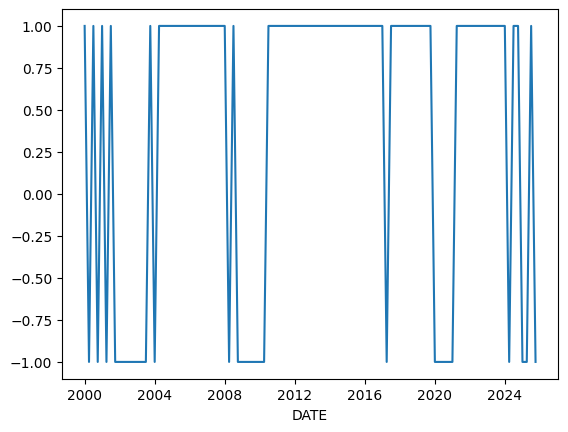

In [45]:
# signals["pos_final_mr"].plot()

In [62]:
# strategy

{'signals_actual':             output_realised  output_forecast  pos_final_mom  pos_final_mr
 DATE                                                                     
 2000-01-14         0.009403         0.000712             -1             1
 2000-04-14         0.001798         0.006943              1            -1
 2000-07-17         0.007257        -0.015021             -1             1
 2000-10-16        -0.002123         0.011726              1            -1
 2001-01-16        -0.005608        -0.012001             -1             1
 ...                     ...              ...            ...           ...
 2024-10-15         0.003100         0.001564             -1             1
 2025-01-15         0.000410         0.002164              1            -1
 2025-04-14        -0.006721        -0.004246              1            -1
 2025-07-15        -0.003433        -0.011759             -1             1
 2025-10-15         0.000310         0.002130              1            -1
 
 [104

In [63]:
# strategy.keys()

dict_keys(['signals_actual', 'fig_pos_momg_SP', 'fig_pnl_cumsum_momg_SP', 'pnl_sum_momg_SP', 'pnl_mean_momg_SP', 'pnl_std_momg_SP', 'sr_daily_momg_SP', 'sr_annual_momg_SP', 'fig_pos_momn_SP', 'fig_pnl_cumsum_momn_SP', 'pnl_sum_momn_SP', 'pnl_mean_momn_SP', 'pnl_std_momn_SP', 'sr_daily_momn_SP', 'sr_annual_momn_SP', 'fig_pos_mrg_SP', 'fig_pnl_cumsum_mrg_SP', 'pnl_sum_mrg_SP', 'pnl_mean_mrg_SP', 'pnl_std_mrg_SP', 'sr_daily_mrg_SP', 'sr_annual_mrg_SP', 'fig_pos_mrn_SP', 'fig_pnl_cumsum_mrn_SP', 'pnl_sum_mrn_SP', 'pnl_mean_mrn_SP', 'pnl_std_mrn_SP', 'sr_daily_mrn_SP', 'sr_annual_mrn_SP'])

In [66]:
# strategy["pnl_sum_momg_SP"]

-0.5084471132887742

In [67]:
# strategy["pnl_sum_momn_SP"]

-0.5103971132887741

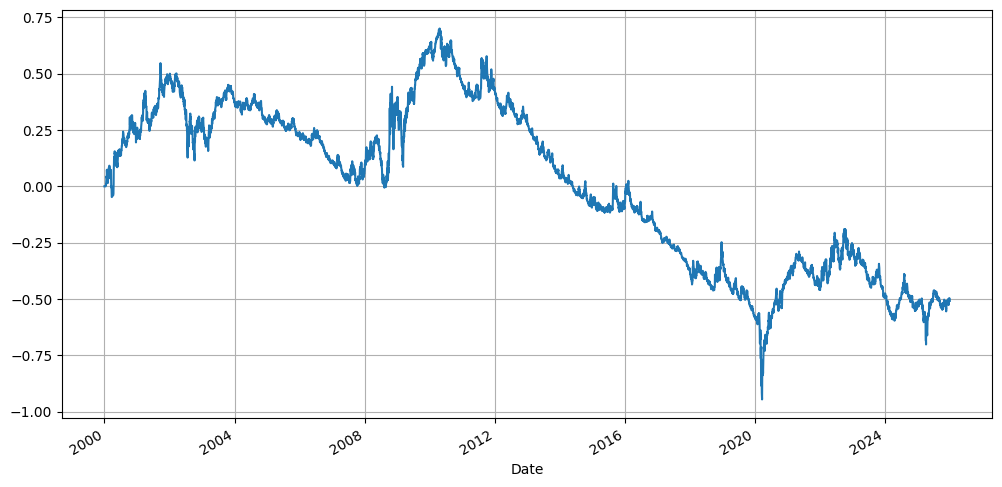

In [64]:
# strategy["fig_pnl_cumsum_momg_SP"]

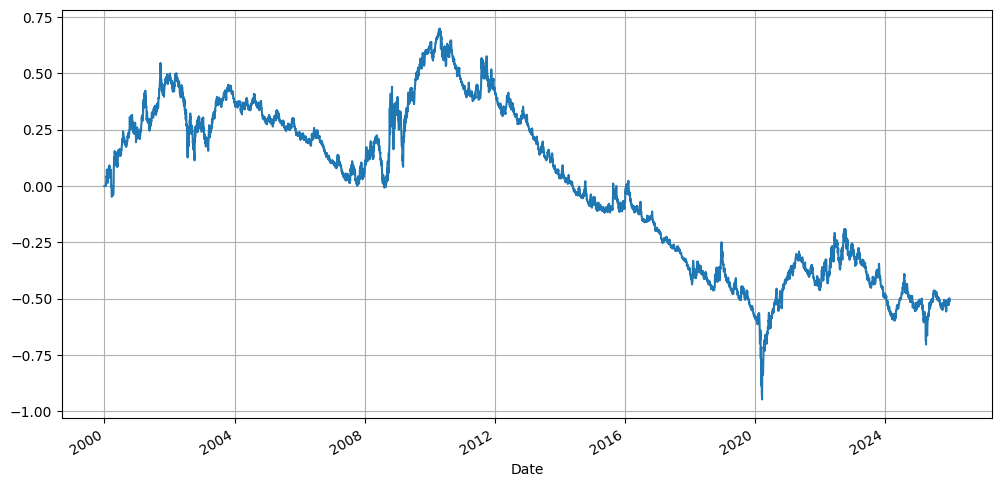

In [65]:
# strategy["fig_pnl_cumsum_momn_SP"]

In [31]:
model_types = ["rbc"]
data_lengths = [5, 10, 20]
windows = [
    [dt.date(1999, 12, 31), dt.date(2025, 9, 30)],
    [dt.date(1999, 12, 31), dt.date(2007, 12, 31)],
    [dt.date(2007, 12, 31), dt.date(2009, 12, 31)],
    [dt.date(2009, 12, 31), dt.date(2019, 12, 31)],
    [dt.date(2019, 12, 31), dt.date(2022, 12, 31)],
    [dt.date(2022, 12, 31), dt.date(2025, 9, 30)],
]
signal_lags = [10, 20, 30]
leverage_cases = [1, 2]
double_down_cases = [False, True]

results = {}
for model_type in model_types:
    rbc = Model(
        model_type, 
        data_10y_19991231_20250930.prod, 
        data_10y_19991231_20250930.gdp, 
        [data_10y_19991231_20250930.asset_sp500, data_10y_19991231_20250930.asset_dow],
        ["SP", "DOW"],
        data_10y_19991231_20250930.holidays
    )

    bh = BuyAndHold(
        [data_10y_19991231_20250930.asset_sp500, data_10y_19991231_20250930.asset_dow],
        ["SP", "DOW"]
    )

    for window in windows:
        window_str = str(window[0]) + "_" + str(window[1])
        results[window_str] = {}
    
        for data_length in data_lengths:
            for signal_lag in signal_lags:
                for leverage in leverage_cases:
                    for double_down in double_down_cases:
                        if not ((data_length == 20) & (window[0] < dt.date(2009, 12, 31))): # GDP data is unavailable before 1989-12-29 so avoid sourcing data before then
                            signals = rbc.generate_signals(data_length, window[0], window[1], leverage, double_down)
                            strategy = rbc.run_strategy(signals, signal_lag, window[0], window[1])
                            
                            key = model_type + "_" + str(data_length) + "cal_" + window_str + "_" + str(signal_lag) + "lag"
                            if leverage > 1:
                                key += "_" + str(leverage) + "lev"
                            if double_down == True:
                                key += "_dd"
                            
                            results[window_str][key] = {"signals": signals, "strategy": strategy}

        strategy_bh = bh.run_strategy(window[0], window[1])
        
        key_bh = "bh_" + window_str
        results[window_str][key_bh] = {"strategy": strategy_bh}


window_prod:

             OPHNFB
DATE               
1999-09-30   70.469
1999-12-31   71.516
2000-03-31   71.222
2000-06-30   72.657
2000-09-29   72.587
...             ...
2024-06-28  114.947
2024-09-30  115.989
2024-12-31  116.394
2025-03-31  116.127
2025-06-30  117.319

[104 rows x 1 columns]
Estimated rho: 0.746
Estimated TFP shock for 1999-09-30: 0.0038
10 [0.00378041]
Next period IRF forecast as of 1999-09-30: 0.00004
Estimated rho: 0.716
Estimated TFP shock for 1999-12-31: 0.0089
10 [0.00891529]
Next period IRF forecast as of 1999-12-31: 0.00697
Estimated rho: 0.586
Estimated TFP shock for 2000-03-31: -0.0067
10 [-0.00668182]
Next period IRF forecast as of 2000-03-31: -0.01405
Estimated rho: 0.461
Estimated TFP shock for 2000-06-30: 0.0107
10 [0.01069896]
Next period IRF forecast as of 2000-06-30: 0.01003
Estimated rho: 0.407
Estimated TFP shock for 2000-09-29: -0.0037
10 [-0.00365668]
Next period IRF forecast as of 2000-09-29: -0.01004
Estimated rho: 0.365
Estimated TFP shock

In [32]:
results

{'1999-12-31_2025-09-30': {'rbc_5cal_1999-12-31_2025-09-30_10lag': {'signals':             output_realised  output_forecast  pos_mom  pos_mr  \
   DATE                                                            
   1999-12-31         0.007371         0.000039       -1       1   
   2000-03-31        -0.000752         0.006967        1      -1   
   2000-06-30         0.004342        -0.014049       -1       1   
   2000-09-29        -0.004938         0.010031        1      -1   
   2000-12-29        -0.008202        -0.010039       -1       1   
   ...                     ...              ...      ...     ...   
   2024-09-30        -0.000452         0.003187        1      -1   
   2024-12-31        -0.004528         0.004879        1      -1   
   2025-03-31        -0.013143        -0.000357        1      -1   
   2025-06-30        -0.010330        -0.006009        1      -1   
   2025-09-30        -0.001583         0.004267        1      -1   
   
               double_down_scalar_mo

In [33]:
main_results_sorted = {}

for window in windows:
    window_str = str(window[0]) + "_" + str(window[1])
    main_results_sorted[window_str] = {}
    
    pnls_spg = []
    pnls_spn = []
    srs_spg = []
    srs_spn = []
    pnls_dowg = []
    pnls_down = []
    srs_dowg = []
    srs_down = []
    
    for strategy in results[window_str].keys():
        if "bh" in strategy:
            pnls_spg.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_SP"]])
            pnls_spn.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_SP"]]) # Assumed g = n for BH
            srs_spg.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_SP"]])
            srs_spn.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_SP"]]) # Assumed g = n for BH
            
            pnls_dowg.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_DOW"]])
            pnls_down.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_DOW"]]) # Assumed g = n for BH
            srs_dowg.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_DOW"]])
            srs_down.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_DOW"]]) # Assumed g = n for BH
        else:
            pnls_spg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["pnl_sum_momg_SP"]])
            pnls_spn.append([strategy + "_momn", results[window_str][strategy]["strategy"]["pnl_sum_momn_SP"]])
            pnls_spg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["pnl_sum_mrg_SP"]])
            pnls_spn.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["pnl_sum_mrn_SP"]])
            srs_spg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["sr_annual_momg_SP"]])
            srs_spn.append([strategy + "_momn", results[window_str][strategy]["strategy"]["sr_annual_momn_SP"]])
            srs_spg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["sr_annual_mrg_SP"]])
            srs_spn.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["sr_annual_mrn_SP"]])

            pnls_dowg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["pnl_sum_momg_DOW"]])
            pnls_down.append([strategy + "_momn", results[window_str][strategy]["strategy"]["pnl_sum_momn_DOW"]])
            pnls_dowg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["pnl_sum_mrg_DOW"]])
            pnls_down.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["pnl_sum_mrn_DOW"]])
            srs_dowg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["sr_annual_momg_DOW"]])
            srs_down.append([strategy + "_momn", results[window_str][strategy]["strategy"]["sr_annual_momn_DOW"]])
            srs_dowg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["sr_annual_mrg_DOW"]])
            srs_down.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["sr_annual_mrn_DOW"]])
    
    main_results_sorted[window_str]["pnls_spg_sorted"] = sorted(pnls_spg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["pnls_spn_sorted"] = sorted(pnls_spn, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_spg_sorted"] = sorted(srs_spg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_spn_sorted"] = sorted(srs_spn, key=lambda x: x[1], reverse=True)
    
    main_results_sorted[window_str]["pnls_dowg_sorted"] = sorted(pnls_dowg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["pnls_down_sorted"] = sorted(pnls_down, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_dowg_sorted"] = sorted(srs_dowg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_down_sorted"] = sorted(srs_down, key=lambda x: x[1], reverse=True)

In [34]:
main_results_sorted.keys()

dict_keys(['1999-12-31_2025-09-30', '1999-12-31_2007-12-31', '2007-12-31_2009-12-31', '2009-12-31_2019-12-31', '2019-12-31_2022-12-31', '2022-12-31_2025-09-30'])

In [35]:
main_results_sorted["1999-12-31_2025-09-30"]["pnls_sp_sorted"]

[['rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd_mr', 3.9755539941841445],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_2lev_dd_mr', 3.695777153533932],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_2lev_dd_mr', 3.2078547049536],
 ['rbc_5cal_1999-12-31_2025-09-30_20lag_2lev_dd_mr', 2.8925227459772103],
 ['rbc_5cal_1999-12-31_2025-09-30_10lag_2lev_dd_mr', 2.6372018798408385],
 ['rbc_10cal_1999-12-31_2025-09-30_10lag_2lev_dd_mr', 2.4748099156563503],
 ['rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_mr', 2.3268963552108834],
 ['bh_1999-12-31_2025-09-30', 2.0262566792516465],
 ['rbc_10cal_1999-12-31_2025-09-30_30lag_dd_mr', 1.9877769970920722],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_2lev_mr', 1.9655817727863252],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_dd_mr', 1.847888576766966],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_2lev_mr', 1.841518941006284],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_dd_mr', 1.6039273524768],
 ['rbc_5cal_1999-12-31_2025-09-30_20lag_dd_mr', 1.4462613729886051],
 ['rbc_5cal_1999-1

In [36]:
main_results_sorted["1999-12-31_2007-12-31"]["pnls_sp_sorted"]

[['rbc_5cal_1999-12-31_2007-12-31_30lag_2lev_dd_mr', 2.2441176173135666],
 ['rbc_5cal_1999-12-31_2007-12-31_20lag_2lev_dd_mr', 2.0241431417493905],
 ['rbc_5cal_1999-12-31_2007-12-31_10lag_2lev_dd_mr', 1.7094188506394732],
 ['rbc_5cal_1999-12-31_2007-12-31_30lag_2lev_mr', 1.1308796109817207],
 ['rbc_5cal_1999-12-31_2007-12-31_30lag_dd_mr', 1.1220588086567833],
 ['rbc_10cal_1999-12-31_2007-12-31_30lag_2lev_dd_mr', 1.0611280991637033],
 ['rbc_5cal_1999-12-31_2007-12-31_20lag_dd_mr', 1.0120715708746952],
 ['rbc_5cal_1999-12-31_2007-12-31_20lag_2lev_mr', 0.9654208420731616],
 ['rbc_5cal_1999-12-31_2007-12-31_10lag_dd_mr', 0.8547094253197366],
 ['rbc_10cal_1999-12-31_2007-12-31_20lag_2lev_dd_mr', 0.7827438662720299],
 ['rbc_5cal_1999-12-31_2007-12-31_30lag_mr', 0.5654398054908604],
 ['rbc_10cal_1999-12-31_2007-12-31_30lag_2lev_mr', 0.5412064278885123],
 ['rbc_10cal_1999-12-31_2007-12-31_30lag_dd_mr', 0.5305640495818517],
 ['rbc_5cal_1999-12-31_2007-12-31_10lag_2lev_mr', 0.5238285592535608],


In [37]:
main_results_sorted["2007-12-31_2009-12-31"]["pnls_sp_sorted"]

[['rbc_10cal_2007-12-31_2009-12-31_10lag_2lev_dd_mom', 1.804524286212798],
 ['rbc_10cal_2007-12-31_2009-12-31_30lag_2lev_dd_mom', 1.7479687007577402],
 ['rbc_5cal_2007-12-31_2009-12-31_30lag_2lev_dd_mom', 1.7174366484845702],
 ['rbc_10cal_2007-12-31_2009-12-31_20lag_2lev_dd_mom', 1.6223284874196304],
 ['rbc_5cal_2007-12-31_2009-12-31_20lag_2lev_dd_mom', 1.5742341794037147],
 ['rbc_5cal_2007-12-31_2009-12-31_10lag_2lev_dd_mom', 1.5060857102256462],
 ['rbc_5cal_2007-12-31_2009-12-31_30lag_2lev_mom', 1.1195434279784497],
 ['rbc_10cal_2007-12-31_2009-12-31_10lag_2lev_mom', 1.0765001911480425],
 ['rbc_5cal_2007-12-31_2009-12-31_20lag_2lev_mom', 1.0026678157952564],
 ['rbc_10cal_2007-12-31_2009-12-31_30lag_2lev_mom', 0.9913705272037796],
 ['rbc_5cal_2007-12-31_2009-12-31_10lag_2lev_mom', 0.948774096532329],
 ['rbc_10cal_2007-12-31_2009-12-31_10lag_dd_mom', 0.902262143106399],
 ['rbc_10cal_2007-12-31_2009-12-31_30lag_dd_mom', 0.8739843503788701],
 ['rbc_10cal_2007-12-31_2009-12-31_20lag_2lev_

In [38]:
main_results_sorted["2009-12-31_2019-12-31"]["pnls_sp_sorted"]

[['rbc_10cal_2009-12-31_2019-12-31_10lag_2lev_dd_mr', 5.194051882557671],
 ['rbc_10cal_2009-12-31_2019-12-31_30lag_2lev_dd_mr', 5.043141855069665],
 ['rbc_20cal_2009-12-31_2019-12-31_10lag_2lev_dd_mr', 5.022873867122584],
 ['rbc_10cal_2009-12-31_2019-12-31_20lag_2lev_dd_mr', 4.806513944357928],
 ['rbc_20cal_2009-12-31_2019-12-31_20lag_2lev_dd_mr', 4.597343919836341],
 ['rbc_20cal_2009-12-31_2019-12-31_30lag_2lev_dd_mr', 4.428528069419309],
 ['rbc_5cal_2009-12-31_2019-12-31_30lag_2lev_dd_mr', 4.172689321860895],
 ['rbc_5cal_2009-12-31_2019-12-31_10lag_2lev_dd_mr', 4.140338671797789],
 ['rbc_5cal_2009-12-31_2019-12-31_20lag_2lev_dd_mr', 3.9527547402810637],
 ['rbc_20cal_2009-12-31_2019-12-31_10lag_2lev_mr', 2.8573724504244726],
 ['rbc_10cal_2009-12-31_2019-12-31_10lag_2lev_mr', 2.8459944810889635],
 ['rbc_10cal_2009-12-31_2019-12-31_30lag_2lev_mr', 2.794071649020876],
 ['rbc_10cal_2009-12-31_2019-12-31_10lag_dd_mr', 2.5970259412788357],
 ['rbc_10cal_2009-12-31_2019-12-31_20lag_2lev_mr', 

In [39]:
main_results_sorted["2019-12-31_2022-12-31"]["pnls_sp_sorted"]

[['rbc_5cal_2019-12-31_2022-12-31_20lag_2lev_dd_mom', 1.4351400875884077],
 ['rbc_10cal_2019-12-31_2022-12-31_20lag_2lev_dd_mom', 1.4351400875884077],
 ['rbc_20cal_2019-12-31_2022-12-31_20lag_2lev_dd_mom', 1.4351400875884077],
 ['rbc_5cal_2019-12-31_2022-12-31_10lag_2lev_dd_mom', 1.3341231883682865],
 ['rbc_10cal_2019-12-31_2022-12-31_10lag_2lev_dd_mom', 1.3341231883682865],
 ['rbc_20cal_2019-12-31_2022-12-31_10lag_2lev_dd_mom', 1.3341231883682865],
 ['rbc_5cal_2019-12-31_2022-12-31_30lag_2lev_dd_mom', 1.2196545323387769],
 ['rbc_10cal_2019-12-31_2022-12-31_30lag_2lev_dd_mom', 1.2196545323387769],
 ['rbc_20cal_2019-12-31_2022-12-31_30lag_2lev_dd_mom', 1.2196545323387769],
 ['rbc_5cal_2019-12-31_2022-12-31_20lag_dd_mom', 0.7175700437942039],
 ['rbc_10cal_2019-12-31_2022-12-31_20lag_dd_mom', 0.7175700437942039],
 ['rbc_20cal_2019-12-31_2022-12-31_20lag_dd_mom', 0.7175700437942039],
 ['rbc_5cal_2019-12-31_2022-12-31_10lag_dd_mom', 0.6670615941841432],
 ['rbc_10cal_2019-12-31_2022-12-31_10

In [40]:
main_results_sorted["2022-12-31_2025-09-30"]["pnls_sp_sorted"]

[['rbc_10cal_2022-12-31_2025-09-30_30lag_2lev_dd_mr', 0.7993730437955542],
 ['rbc_20cal_2022-12-31_2025-09-30_30lag_2lev_dd_mr', 0.7993730437955542],
 ['rbc_10cal_2022-12-31_2025-09-30_30lag_2lev_mr', 0.6382310457566633],
 ['rbc_20cal_2022-12-31_2025-09-30_30lag_2lev_mr', 0.6382310457566633],
 ['bh_2022-12-31_2025-09-30', 0.6161665432802396],
 ['rbc_10cal_2022-12-31_2025-09-30_20lag_2lev_dd_mr', 0.5632396734762868],
 ['rbc_20cal_2022-12-31_2025-09-30_20lag_2lev_dd_mr', 0.5632396734762868],
 ['rbc_10cal_2022-12-31_2025-09-30_20lag_2lev_mr', 0.5439030025047218],
 ['rbc_20cal_2022-12-31_2025-09-30_20lag_2lev_mr', 0.5439030025047218],
 ['rbc_5cal_2022-12-31_2025-09-30_30lag_2lev_dd_mr', 0.41573957431871267],
 ['rbc_10cal_2022-12-31_2025-09-30_30lag_dd_mr', 0.3996865218977771],
 ['rbc_20cal_2022-12-31_2025-09-30_30lag_dd_mr', 0.3996865218977771],
 ['rbc_5cal_2022-12-31_2025-09-30_30lag_2lev_mr', 0.36092051175585804],
 ['rbc_10cal_2022-12-31_2025-09-30_10lag_2lev_dd_mr', 0.3426120875657028],

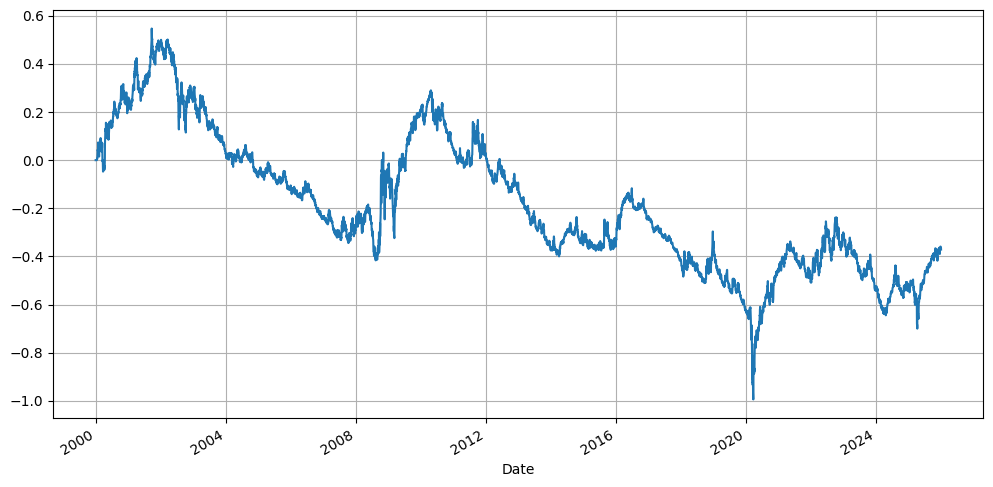

In [52]:
results["1999-12-31_2025-09-30"]["rbc_5cal_1999-12-31_2025-09-30_10lag"]["strategy"]["fig_pnl_cumsum_mom_SP"]